In [34]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [35]:
import sys
sys.path.append('../../utils')
from functions import * 

In [36]:
# Metadata file:
metadata_file = '/gpfs/commons/groups/knowles_lab/data/tabula_muris/smart_seq/d8a0c006-2991-5ddb-8ed8-7b7e8c187fe3/all_tabula_muris_samples_w_celltype_column.txt'
metadata = pd.read_csv(metadata_file, sep='\t', index_col=0)
print("Loaded metadata file!")
print_separator()

organ = 'Brain'

# Subset the metadata file to only include the organ of interest:
metadata = metadata[metadata['tissue'].str.contains(organ)]
print("The number of cells in the metadata corresponding to the organ of interest is: " + str(len(metadata.index)))
print_separator()

Loaded metadata file!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The number of cells in the metadata corresponding to the organ of interest is: 7856
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [37]:
metadata["cell_id"] = metadata.index
metadata.head()

,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type,cell_id
cell,,,,,,,
A1-B003290-3_38_F-1-1,astrocyte,NaN,3_38_F,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-B003290-3_38_F-1-1
A1-B003728-3_56_F-1-1,astrocyte,NaN,3_56_F,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-B003728-3_56_F-1-1
A1-MAA000560-3_10_M-1-1,oligodendrocyte,NaN,3_10_M,Cortex,Brain_Non-Myeloid,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1
A1-MAA000564-3_10_M-1-1,endothelial cell,NaN,3_10_M,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_endothelial_cell,A1-MAA000564-3_10_M-1-1
A1-MAA000923-3_9_M-1-1,astrocyte,NaN,3_9_M,Hippocampus,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-MAA000923-3_9_M-1-1


In [38]:
# keep cell_type as everything after "Myeloid_"
metadata.cell_type = metadata.cell_type.str.split("Myeloid_").str[1]
metadata.cell_type.unique() 

array(['astrocyte', 'oligodendrocyte', 'endothelial_cell', 'neuron',
       'oligodendrocyte_precursor_cell', 'Bergmann_glial_cell',
       'brain_pericyte', 'microglial_cell', 'macrophage'], dtype=object)

In [39]:
# load PCA and UMAP representations of brain data using gene counts 
PCA_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_pca_embedding.csv')
UMAP_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_umap_embedding.csv')

#Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')
Leaflet_rep = pd.read_csv('/gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/Leaflet/simple_data_junc_548.csv')

In [40]:
UMAP_rep.drop(columns=['Unnamed: 0'], inplace=True)
UMAP_rep.drop(columns = ['cell_type'], inplace=True)

In [41]:
UMAP_rep = UMAP_rep.merge(metadata, on=['cell_id'], how='left')

In [42]:
Leaflet_rep = Leaflet_rep[["cell_id", "junc_ratio"]]
Leaflet_rep["cell_id"] = Leaflet_rep["cell_id"].str.split("_Brain").str[0]
Leaflet_rep

KeyError: "['cell_id'] not in index"

In [ ]:
# combine UMAP and BB mixture results
UMAP_rep = UMAP_rep.merge(Leaflet_rep, on='cell_id', how='left')

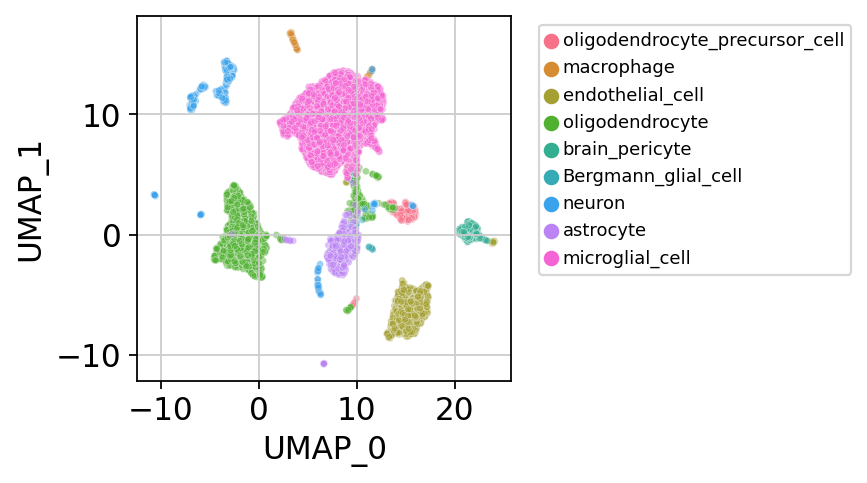

oligodendrocyte_precursor_cell: (0.9677975592919913, 0.44127456009157356, 0.5358103155058701)
macrophage: (0.8369430560927636, 0.5495828952802333, 0.1952683223448124)
endothelial_cell: (0.6430915736746491, 0.6271955086583126, 0.19381135329796756)
oligodendrocyte: (0.3126890019504329, 0.6928754610296064, 0.1923704830330379)
brain_pericyte: (0.20582072623426667, 0.6842209016721069, 0.5675558225732941)
Bergmann_glial_cell: (0.2151139535594307, 0.6700707833028816, 0.7112365203426209)
neuron: (0.23299120924703914, 0.639586552066035, 0.9260706093977744)
astrocyte: (0.731751635642941, 0.5128186367840487, 0.9581005178234921)
microglial_cell: (0.9614880299080136, 0.3909885385134758, 0.8298287106954371)


In [ ]:
# 1. Define a color palette for 'cell_type'
unique_cell_types = UMAP_rep['cell_type'].unique()
palette = sns.color_palette("husl", len(unique_cell_types))
color_mapping = dict(zip(unique_cell_types, palette))

# Plot
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['cell_type'], palette=color_mapping, alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

# Print color mapping for reference
for cell_type, color in color_mapping.items():
    print(f"{cell_type}: {color}")

<Axes: >

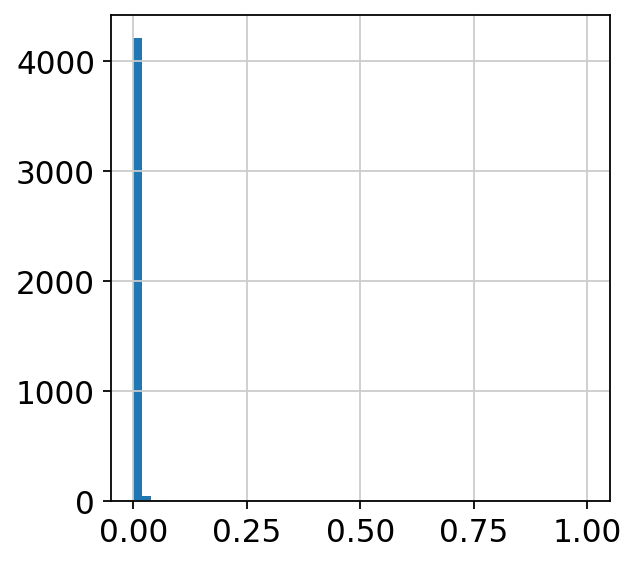

In [ ]:
filt_dat.junc_ratio.hist(bins=50)

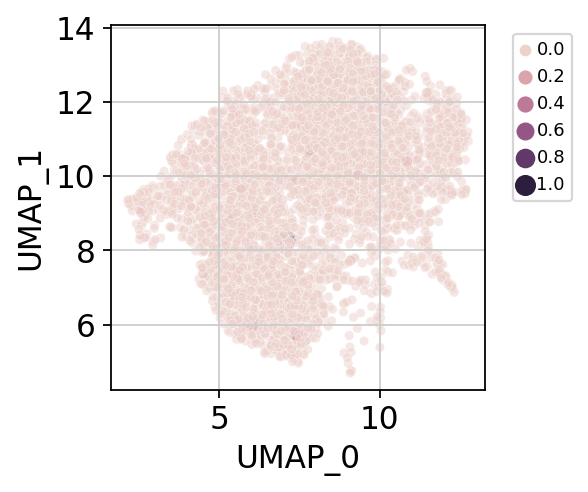

In [30]:
# 1. Filter the dataframe
filt_dat = UMAP_rep[UMAP_rep['cell_type'] == "microglial_cell"]

# 2. & 3. Plot using hue and the subset color mapping
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['junc_ratio'], size=filt_dat['junc_ratio'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

### basically gene expression can't really seperate macrophages 

In [ ]:
UMAP_rep[UMAP_rep["cell_type"] == "macrophage"][("cellassignment")].value_counts()

In [ ]:
UMAP_rep[UMAP_rep["cell_type"] == "microglial_cell"][("cellassignment")].value_counts()

In [ ]:
UMAP_rep[UMAP_rep["cell_type"] == "brain_pericyte"][("cellassignment")].value_counts()

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['subtissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['tissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
UMAP_rep["cellassignment"].value_counts()

In [ ]:
subset_colors = {k: color_mapping[k] for k in filt_dat['cell_type'].unique() if k in color_mapping}

filt_dat = UMAP_rep[UMAP_rep['cellassignment'].isin(['CellState_7', 'CellState_8', 'CellState_9'])]
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], style=filt_dat['cellassignment'], hue=filt_dat['cell_type'], palette=subset_colors, alpha=0.5, s=18)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

In [ ]:
UMAP_rep[["cellassignment", "mouse.id"]][["mouse.id", "cellassignment"]].value_counts()

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['mouse.id'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()